# Pearson's correlation coefficient

Let's start with **covariance** 

$$
\operatorname{Cov}(X,Y)
=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$

Quick intuition:
- in the numerator for an observation same signs (both above average or both below average)  means increase, different signs means decrease
- the denominator just makes the size of the covariance independent of the sample size (obviously we do not what the covariance to double with double the sample size)

Problem - the covariance has units of unit1 x unit2. This is unintuitive and it is difficult to give meaning to the actual numeric value.
Remember that standard deviations also had the unit of the variable: 

$$
s_x
=
\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}},
\qquad
s_y
=
\sqrt{\frac{\sum_{i=1}^{n}(y_i-\bar{y})^2}{n-1}}.
$$

Solution: Remove the units and normalize the magnitude by dividing the covariance by the standard deviations for each variable.


**Pearson's correlation coefficient**
$$
r 
= 
\frac{\operatorname{Cov}(X,Y)}{s_x s_y}
=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

The interpretation is straightforward:

- **Covariance** measures how much two variables move together.
- **Standard deviations** measure how much each variable varies individually.
- **Correlation** measures the co-movement relative to the total variation, making it **unitless** and always bounded between **-1 and 1**.

In [61]:
### Example 1 - any linear relationship results in perfect correlation

import numpy as np

# Positive x values
x = np.linspace(0, 4, 100)  # 100 evenly spaced points between 0 and 4

print(f" Perfect Correlation:      {np.corrcoef(x, x*2 +17)[0, 1]:.3f}")

 Perfect Correlation:      1.000


In [58]:
### Example 2 - corrlation of squares

print(f" Correlation of positive x and x^2:      {np.corrcoef(x, x**2)[0, 1]:.3f}")

# Negative x values
x_neg = -x

print(f" Correlation of negative x vs x^2:      {np.corrcoef(x_neg, x_neg**2)[0, 1]:.3f}")

# Combine both datasets
x_all = np.concatenate([x_neg, x])

print(f" Combined data:     {np.corrcoef(x_all, x_all**2)[0, 1]:.3f}")

 Correlation of positive x and x^2:      0.968
 Correlation of negative x vs x^2:      -0.968
 Combined data:     -0.000


**Positive correlation** - the values grow together.

**Negative correlation** - the $x$ decreases, but $x^2$ grows

**Zero** - no linear relationship 


## Important:
- The correlation is not 1 because the relationship is not linear.
- However no linear relationsip does not mean no relationship at all!

Pearson's correlation does **not** ask:

> "Can I predict $y$ exactly from $x$?"

It asks:

> "How close are the points to a straight line?"


For example, if we make the power 4, it becomes even less linear:

In [34]:
### Power of 4 
print(f" Correlation of positive x and x^4:      {np.corrcoef(x, x**4)[0, 1]:.3f}")
print(f" Correlation of negative x vs x^4:      {np.corrcoef(x_neg, x_neg**4)[0, 1]:.3f}")
print(f" Combined data:     {np.corrcoef(x_all, x_all**4)[0, 1]:.3f}")

 Correlation of positive x and x^4:      0.865
 Correlation of negative x vs x^4:      -0.865
 Combined data:     0.000


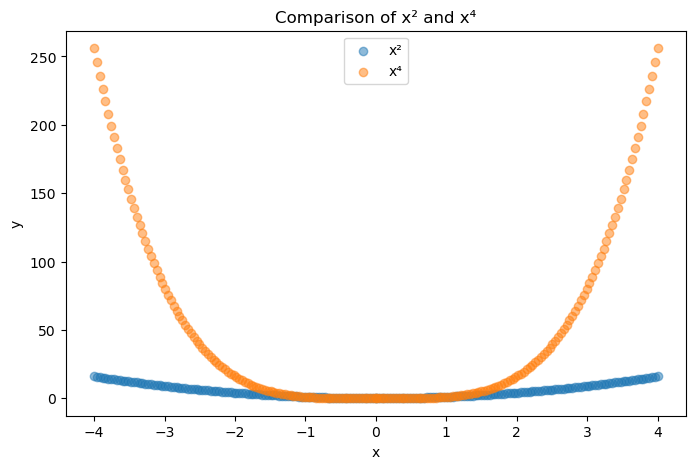

In [41]:
# normally we would draw this on a log scale, 
# however this actually shows better how much more "linear" the square is compared to the power of 4 

import matplotlib.pyplot as plt

# assuming x_all already exists
y_squared = x_all**2
y_fourth = x_all**4

plt.figure(figsize=(8, 5))

plt.scatter(x_all, y_squared, label="x²", alpha=0.5)
plt.scatter(x_all, y_fourth, label="x⁴", alpha=0.5)



plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of x² and x⁴")
plt.legend()

plt.show()

## Pearson correlation is invariant to scaling and shifting

Pearson's correlation does not change when we multiply or add constants to the variables.

### Multiplication (changing scale)

If we multiply a variable by a constant:

$$
x' = ax
$$

### Addition (shifting values)

If we add a constant:

$$
x'=x+b
$$


This is why correlation is **unitless**:

- measuring height in meters or centimeters gives the same correlation;
- measuring money in euros or dollars gives the same correlation;
- shifting a temperature scale does not change the correlation (Celsius → Kelvin → Fahrenheit are all linear transformations)

Changing the units changes the numbers, but it does not change the underlying relationship.

In [24]:
# shifted correlation

print(f" Shifted correlation with power of 4 :      {np.corrcoef(x*3 + 15, (x**4)*3 + 15)[0, 1]:.3f}")

 Shifted correlation with power of 4 :      0.865


## Geometric interpretation of Pearson's correlation

Pearson's correlation can also be understood as the angle between two vectors.

First, we center both variables by subtracting their means:

$$
X_c = X-\bar{X}
$$

$$
Y_c = Y-\bar{Y}
$$

These centered variables can be viewed as vectors:

$$
X_c = (x_1-\bar{x}, x_2-\bar{x}, ..., x_n-\bar{x})
$$

$$
Y_c = (y_1-\bar{y}, y_2-\bar{y}, ..., y_n-\bar{y})
$$

The Pearson correlation coefficient is:

$$
r =
\frac{X_c \cdot Y_c}
{\|X_c\|\|Y_c\|}
$$

This is the same formula as the cosine of the angle between two vectors:

$$
\cos(\theta)
=
\frac{A \cdot B}{\|A\|\|B\|}
$$

Therefore:

$$
r=\cos(\theta)
$$

The correlation is describing how closely the two centered variables point in the same direction.

- \(r=1\): the vectors point in the same direction  
  (perfect positive linear relationship)

- \(r=0\): the vectors are perpendicular  
  (no linear relationship)

- \(r=-1\): the vectors point in opposite directions  
  (perfect negative linear relationship)

This also explains why Pearson's correlation is always between:

$$
-1 \leq r \leq 1
$$

because cosine values can only exist in that range.

The key intuition:

> Correlation is not measuring whether two variables are connected. It measures how similar their patterns of variation are after removing their averages.

In [45]:
## Example  with x and x**2

# x = np.linspace(0, 4, 100) already exists
y = x**2

# Center the vectors (subtract mean)
x_centered = x - np.mean(x)
y_centered = y - np.mean(y)

# Normalize into unit vectors
x_normalized = x_centered / np.linalg.norm(x_centered)
y_normalized = y_centered / np.linalg.norm(y_centered)

# Cosine similarity = dot product of normalized vectors
cosine = np.dot(x_normalized, y_normalized)

print(f"Cosine between centered vectors: {cosine:.3f}")

# Compare with Pearson correlation
print(f"Pearson correlation:             {np.corrcoef(x, y)[0,1]:.3f}")

Cosine between centered vectors: 0.968
Pearson correlation:             0.968


## Outliers and Pearson correlation

Pearson correlation is sensitive to outliers because the calculation uses the values of all observations.

A single extreme value can have a large influence on the correlation coefficient and make the relationship appear stronger or weaker than it actually is.

This means that a high or low correlation value may sometimes be caused by a few unusual observations rather than the overall pattern in the data.

Therefore, before interpreting Pearson correlation, it is important to visualize the data and check for potential outliers.

In [50]:
x_outlier = np.append(x, 5)
y_outlier = np.append(y, 100)   # extreme y value, was supposed to be 25

# Correlation with outlier
corr_outlier = np.corrcoef(x_outlier, y_outlier)[0, 1]

print(f"Correlation with outlier:    {corr_outlier:.3f}")

Correlation with outlier:    0.648


## Relationship between Pearson correlation and R² in simple linear regression results

In a simple linear regression with one predictor, the coefficient of determination ($R^2$) is directly related to Pearson correlation:

$$
R^2 = r^2
$$

where:

- $r$ = Pearson correlation between the predictor and response
- $R^2$ = proportion of variance in the response explained by the linear model

Therefore, if we square the correlation coefficient, we should get the same value as the $R^2$ reported by an OLS regression.

This relationship only holds for **simple linear regression with one predictor**. In multiple regression models, $R^2$ is no longer simply the squared correlation.

In [60]:
import statsmodels.api as sm


# Pearson correlation
corr = np.corrcoef(x, y)[0, 1]

# Add intercept for OLS
X = sm.add_constant(x)

# Fit linear regression
model = sm.OLS(y, X).fit()

# Show regression summary
print(model.summary())

# Compare values
print(f"Pearson correlation: {corr:.6f}")
print(f"Squared correlation: {corr**2:.6f}")
print(f"OLS R²:              {model.rsquared:.6f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     1441.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           2.04e-60
Time:                        17:40:05   Log-Likelihood:                -161.49
No. Observations:                 100   AIC:                             327.0
Df Residuals:                      98   BIC:                             332.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6397      0.244    -10.821      0.0

Remember - the $R^2$ is the percentage of the variance the linear regression model explains. The remaining ~6% is the error caused by the curvature that a linear model cannot capture.

In [63]:
# By the way pandas gives a correlation matrix too

import pandas as pd

data = pd.DataFrame({
    "x": x,
    "x^2": x**2,
    "x^4": x**4
})

data.corr()

,x,x^2,x^4
x,1.000000,0.967644,0.864846
x^2,0.967644,1.000000,0.958183
x^4,0.864846,0.958183,1.000000


## Correlation in practice

Correlation is useful for quickly identifying patterns between variables, but it does not explain why variables are related.

A high correlation does not tell us:
- whether one variable causes the other
- whether the relationship is linear in all regions
- whether the result is driven by outliers
- whether other variables explain the relationship

Correlation is therefore a starting point for investigation rather than a final answer.